<a href="https://colab.research.google.com/github/sumbal82/Email-spam-classifier/blob/main/email_spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("/mail_data.csv")

In [17]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,0
Category,0
Message,0


In [18]:
df['Message'] = df['Message'].fillna("")
df['Category'] = df['Category'].fillna("ham")

In [19]:
y = df['Category'].map({'ham': 0, 'spam': 1})

In [20]:
tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(df['Message'])

print(X.shape)

(5572, 8440)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [22]:
model = SVC(kernel='linear')

model.fit(X_train, y_train)

SVC(kernel='linear')

In [26]:
y_pred = model.predict(X_test)

In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9820627802690582
Precision: 0.9923664122137404
Recall: 0.87248322147651
F1 Score: 0.9285714285714286


In [25]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[965   1]
 [ 19 130]]


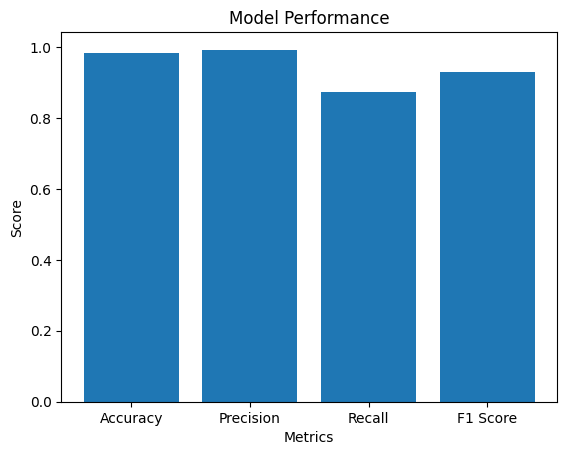

In [27]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()